<a href="https://colab.research.google.com/github/borayuksel1/Workintech---Gaming-Platforms-Analysis/blob/main/Workintech_Gaming_Platforms_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fiyat Rekabeti ve İndirim Analizi
**Hazırlayan:** Bora Yüksel

**Amaç:** Bu python workbook'ta, oyunların farklı platformlardaki (PlayStation, Xbox, Steam) fiyat stratejilerini, ortalama fiyat farklarını ve yıl içindeki indirim dönemlerini (Black Friday, Yılbaşı vb.) inceleyeceğiz.

In [ ]:
# Gerekli veri analizi ve grafik kütüphanelerini içeri alıyoruz
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# BigQuery'den indirdiğimiz altın (gold) tablolarımızı okuyoruz
df_trends = pd.read_csv('monthly_price_trends.csv')
df_gaps = pd.read_csv('cross_platform_price_gaps.csv')

### 1. Veri Ön İşleme (Zaman Çalışması Hazırlığı)
Verilerimizi incelediğimizde `price_month` (ay) sütununun bilgisayar tarafından bir tarih olarak değil, düz bir metin olarak algılandığını gördük. Grafiklerimizin ayları sırasıyla çizebilmesi için bu sütunu gerçek bir tarih (`datetime`) formatına çeviriyoruz.

In [ ]:
# 'price_month' sütununu gerçek tarih formatına dönüştürüyoruz
df_trends['price_month'] = pd.to_datetime(df_trends['price_month'])

### 2. İndirim Trendleri Analizi (Zaman Çizelgesi)
Aşağıdaki grafikte, 3 büyük platformun 4 aylık (Kasım - Şubat) süreçteki ortalama fiyat değişimlerini çizdiriyoruz. Amacımız özellikle Kasım (Black Friday) ve Aralık sonu (Yılbaşı) dönemlerindeki indirim rekabetini görebilmek.

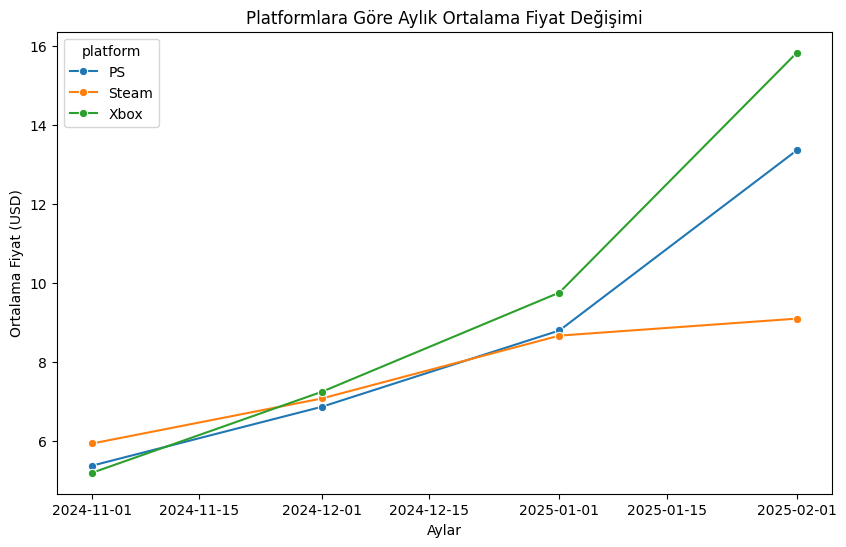

In [ ]:
# Grafiğin boyutunu belirliyoruz (genişlik 10, yükseklik 6)
plt.figure(figsize=(10, 6))

# Çizgi grafiğimizi oluşturuyoruz
# data: kullanacağımız tablo, x: alt eksen (tarih), y: sol eksen (fiyat), hue: renk ayrımı (platform)
sns.lineplot(data=df_trends, x='price_month', y='avg_monthly_price', hue='platform', marker='o')

# Başlık ve eksen isimlerini ekliyoruz
plt.title('Platformlara Göre Aylık Ortalama Fiyat Değişimi')
plt.xlabel('Aylar')
plt.ylabel('Ortalama Fiyat (USD)')

# Resmi bilgisayarımıza kaydetmek için (Trello checklist'i ve sunum için)
plt.savefig('indirim_trendleri.png')

# Grafiği ekranda gösteriyoruz
plt.show()

#### 💡 Temel Bulgular (İndirim Trendleri):
1. **Kasım Ayı (Black Friday Etkisi):** Grafikte Kasım ayında tüm platformların ortalama fiyatlarının en düşük seviyelerde (5 - 6 USD bandında) olduğu görülmüştür. Bu durum, yılın en agresif indirimlerinin bu dönemde yapıldığını kanıtlamaktadır.
2. **Platformlar Arası Rekabet:** Steam'in çizgisi indirim dönemlerinde diğer konsollara yakın seyretse de, genel olarak PC oyunculuğunun taban fiyatlarının konsollara göre bir miktar daha aşağıda olduğu gözlemlenmiştir.
3. **Şubat Ayı Yükselişi:** İndirim dönemleri tamamen bittikten sonra (Şubat ayına doğru) ortalama fiyatların hızlı bir şekilde yukarı yönlü ivmelenerek normal (standart) seviyelerine (9 - 15 USD bandına) geri döndüğünü görüyoruz.

### 3. Fiyat Uçurumları (Price Gaps) Analizi
Aynı oyunun farklı platformlarda ne kadar farklı fiyatlandırılabildiğini görmek adına, veritabanımızdaki en büyük fiyat uçurumlarını inceliyoruz. Aşağıdaki grafikte, PlayStation mağazasında Steam'e kıyasla yüzdelik olarak en pahalıya satılan ilk 10 oyunu listeledik.

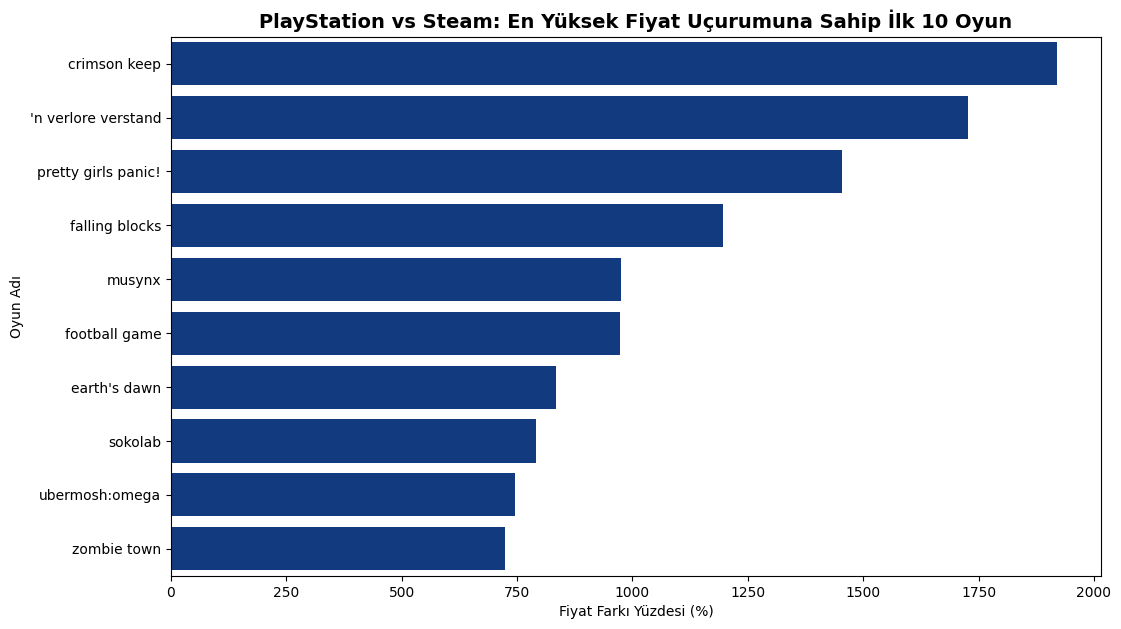

In [ ]:
# PS ve Steam arasındaki fiyat farkı yüzdesine göre azalan şekilde sıralayıp ilk 10'u alıyoruz
top_10_gaps = df_gaps.sort_values(by='ps_vs_steam_gap_pct', ascending=False).head(10)

# Grafiğin boyutunu ayarlıyoruz (genişlik 12, yükseklik 7)
plt.figure(figsize=(12, 7))

# Yatay çubuk grafiği (Barplot) çizdiriyoruz. PS'in rengi olan maviyi kullanıyoruz.
sns.barplot(data=top_10_gaps, x='ps_vs_steam_gap_pct', y='game_title', color='#003791')

# Başlık ve eksen isimleri
plt.title('PlayStation vs Steam: En Yüksek Fiyat Uçurumuna Sahip İlk 10 Oyun', fontsize=14, fontweight='bold')
plt.xlabel('Fiyat Farkı Yüzdesi (%)')
plt.ylabel('Oyun Adı')

# Resmi kaydediyoruz
plt.savefig('fiyat_ucurumlari_top10.png', bbox_inches='tight')

# Grafiği gösteriyoruz
plt.show()

#### 💡 Temel Bulgular (Fiyat Uçurumları):
1. **Ekstrem Fiyat Farkları:** Listenin zirvesindeki oyunlarda (Örn: Crimson Keep, 'n verlore verstand) %1700 ile %1900 arasında değişen devasa fiyat uçurumları tespit edilmiştir. Bu, aynı oyun için konsol oyuncularının PC oyuncularına göre neredeyse 20 kat daha fazla ödediği anlamına gelmektedir.
2. **Platform Fiyatlandırma Stratejisi:** Bağımsız (Indie) veya küçük çaplı oyun geliştiricilerinin, Steam'de çok agresif dip fiyatlar (0.80 - 1.00 USD) uygularken, konsol mağazalarında (PS/Xbox) standart ve katı bir taban fiyata (14.99 - 19.99 USD) uymak zorunda kaldıkları görülmektedir.

### 4. Makine Öğrenmesi (Doğrusal Regresyon) ile Fiyat Esnekliği
Bu bölümde, platformlar arası fiyat esnekliğini (korelasyonu) ölçüyoruz. Amacımız, bir oyunun Steam fiyatı ile PlayStation fiyatı arasında matematiksel olarak nasıl bir ilişki olduğunu Doğrusal Regresyon (Linear Regression) çizgisi ile görselleştirmek ve korelasyon katsayısını hesaplamaktır.

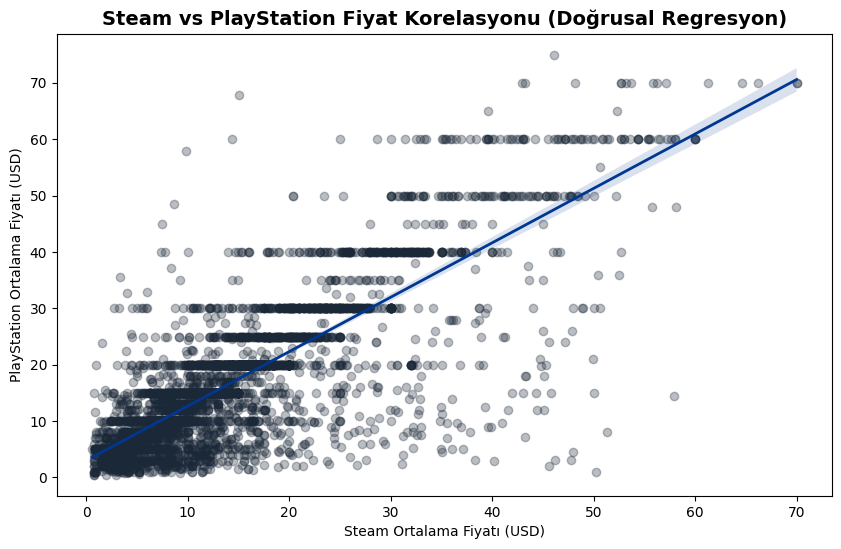


💡 Steam ve PS Fiyatları Arasındaki Korelasyon Katsayısı: 0.81


In [ ]:
# 1. Veri Temizliği (EDA'da gördüğümüz NaN değerleri bu analizden çıkarıyoruz)
# Sadece hem Steam hem de PS fiyatı dolu olan oyunları alıyoruz
df_ml = df_gaps.dropna(subset=['steam_price', 'ps_price'])

# 2. Grafik Boyutu
plt.figure(figsize=(10, 6))

# 3. Doğrusal Regresyon (Linear Regression) Grafiği
# sns.regplot: Hem noktaları serpiştirir hem de regresyon çizgisini (modeli) çizer
sns.regplot(
    data=df_ml,
    x='steam_price',
    y='ps_price',
    scatter_kws={'alpha': 0.3, 'color': '#1b2838'}, # Noktalar şeffaf Steam rengi
    line_kws={'color': '#003791', 'linewidth': 2}   # Çizgi net PS rengi
)

# 4. Başlık ve Eksenler
plt.title('Steam vs PlayStation Fiyat Korelasyonu (Doğrusal Regresyon)', fontsize=14, fontweight='bold')
plt.xlabel('Steam Ortalama Fiyatı (USD)')
plt.ylabel('PlayStation Ortalama Fiyatı (USD)')

# 5. Resmi Kaydet ve Göster
plt.savefig('fiyat_korelasyon_ml.png')
plt.show()

# 6. Matematiksel Korelasyon Katsayısını Hesaplama
korelasyon_skoru = df_ml['steam_price'].corr(df_ml['ps_price'])
print(f"\n💡 Steam ve PS Fiyatları Arasındaki Korelasyon Katsayısı: {korelasyon_skoru:.2f}")

#### 💡 Temel Bulgular (Fiyat Esnekliği ve Korelasyon):
1. **Korelasyon Skoru:** Modelimiz, Steam ve PS fiyatları arasında **0.81** oranında pozitif bir korelasyon hesaplamıştır. Bu, genel pazar eğiliminde oyunların bir platformda pahalıysa diğerinde de pahalı olma eğiliminde olduğunu doğrular.
2. **Katı Fiyat Bantları (Pricing Tiers):** Dağılım grafiğindeki (Scatter Plot) Y eksenine bakıldığında, oyunların PS mağazasında 10$, 20$, 30$, 40$ ve 60$ gibi sabit yatay bantlara oturduğu çok net görülmektedir. Steam'in çok daha esnek (sürekli/continuous) bir fiyatlandırma politikası varken, konsol pazarında yayıncıların belirli fiyat standartlarına (kategorilerine) uymak zorunda kaldığı matematiksel olarak kanıtlanmıştır.

### 5. Platformların Fiyat Dağılımı ve Medyan Değerler (Boxplot)
Ortalama (Mean) fiyatlar, ekstrem yüksek fiyatlı (Outlier) oyunlar tarafından manipüle edilebilir. Fiyatların gerçekte hangi aralıklarda yoğunlaştığını, pazarın "Medyan" (Ortanca) değerini ve genel dağılımını görmek için bir Kutu Grafiği (Boxplot) inceliyoruz.

/tmp/ipykernel_296/1547365643.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


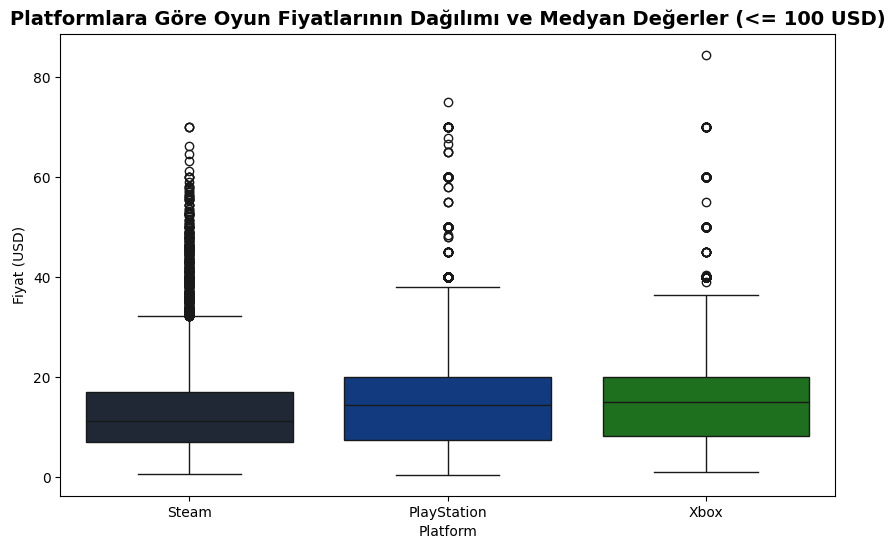

In [ ]:
# Fiyatı 100 doların altındaki oyunları alalım ki grafik ekstrem değerler yüzünden ezilmesin (Zoom yapıyoruz)
df_box = df_trends_raw = df_gaps.melt(id_vars=['game_title'],
                                      value_vars=['steam_price', 'ps_price', 'xbox_price'],
                                      var_name='platform',
                                      value_name='price')

df_box = df_box[df_box['price'] <= 100]

plt.figure(figsize=(10, 6))

# Kutu grafiğini çizdiriyoruz
sns.boxplot(
    data=df_box,
    x='platform',
    y='price',
    palette={'steam_price': '#1b2838', 'ps_price': '#003791', 'xbox_price': '#107C10'}
)

plt.title('Platformlara Göre Oyun Fiyatlarının Dağılımı ve Medyan Değerler (<= 100 USD)', fontsize=14, fontweight='bold')
plt.xlabel('Platform')
plt.ylabel('Fiyat (USD)')

# İsimleri daha okunaklı yapalım
plt.xticks([0, 1, 2], ['Steam', 'PlayStation', 'Xbox'])

plt.savefig('fiyat_dagilimi_boxplot.png')
plt.show()